Loaded 21 timesteps
Final age: 1.00 Gyr
Luminosity range: -5.742 to -1.808


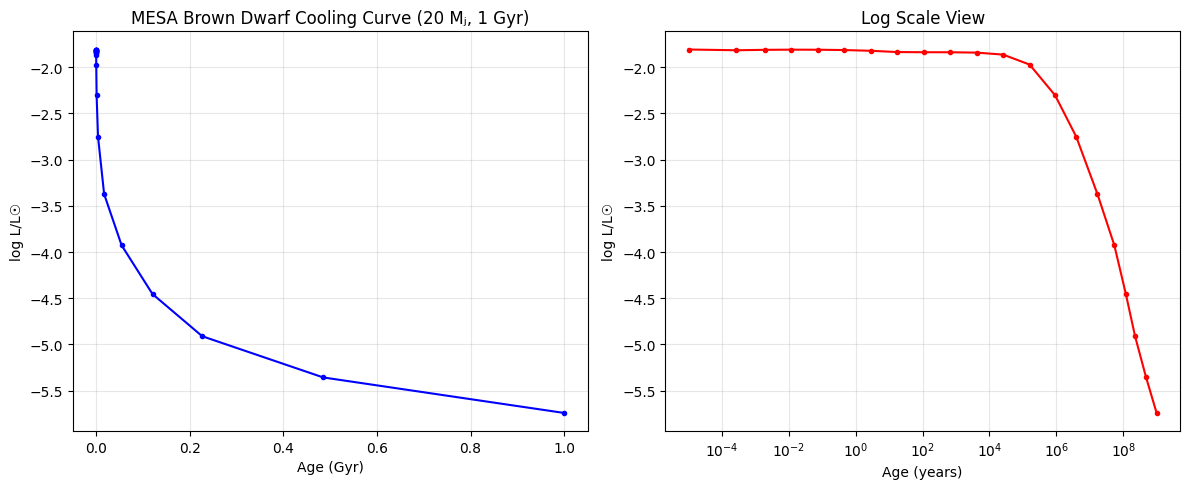

In [1]:
import mesa_reader as mr
import matplotlib.pyplot as plt
import numpy as np

history = mr.MesaData('LOGS/history.data')

# Extract cooling curve
ages_yr = history.star_age
log_L = history.log_L

# Convert age to Gyr
ages_gyr = ages_yr / 1e9

sort_idx = np.argsort(ages_yr)
ages_yr = ages_yr[sort_idx]
log_L = log_L[sort_idx]

unique_idx = np.unique(ages_yr, return_index=True)[1]
ages_yr = ages_yr[unique_idx]
log_L = log_L[unique_idx]

print(f"Loaded {len(ages_yr)} timesteps")
print(f"Final age: {ages_yr[-1]/1e9:.2f} Gyr")
print(f"Luminosity range: {log_L.min():.3f} to {log_L.max():.3f}")

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ages_gyr, log_L, 'b-o', linewidth=1.5, markersize=3)
plt.xlabel('Age (Gyr)')
plt.ylabel('log L/L☉')
plt.title('MESA Brown Dwarf Cooling Curve (20 Mⱼ, 1 Gyr)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(ages_yr, log_L, 'r-o', linewidth=1.5, markersize=3)
plt.xlabel('Age (years)')
plt.ylabel('log L/L☉')
plt.title('Log Scale View')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('brown_dwarf_cooling.png', dpi=150)
plt.show()

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


STEP 1: LOAD MESA BROWN DWARF DATA FROM MAKE_BROWN_DWARF_SURR
Loaded timesteps: 21
Final age: 1.0000 Gyr

STEP 2: INTERPOLATE ONTO STANDARD AGE GRID
Age grid points: 50

STEP 3: BUILD TRAINING DATASET
Total stellar models: 15
Total rows: 750

STEP 4: GROUP-BASED TRAIN/TEST SPLIT
Train rows: 600
Test rows: 150

STEP 5: FEATURE SCALING

STEP 6: TRAINING GAUSSIAN PROCESS (SUBSAMPLED)
GP training complete on 600 samples

STEP 7: TRAINING RANDOM FOREST (300 trees)
RF training complete

STEP 8: EVALUATION METRICS
Gaussian Process   MAE = 0.235815   R² = 0.988950
Random Forest      MAE = 0.032042   R² = 0.999715
Ensemble (70% GP, 30% RF) MAE = 0.165193   R² = 0.994503

STEP 9: 20 Mⱼ BROWN DWARF REALISTIC PREDICTIONS

STEP 10: GENERATING PLOTS


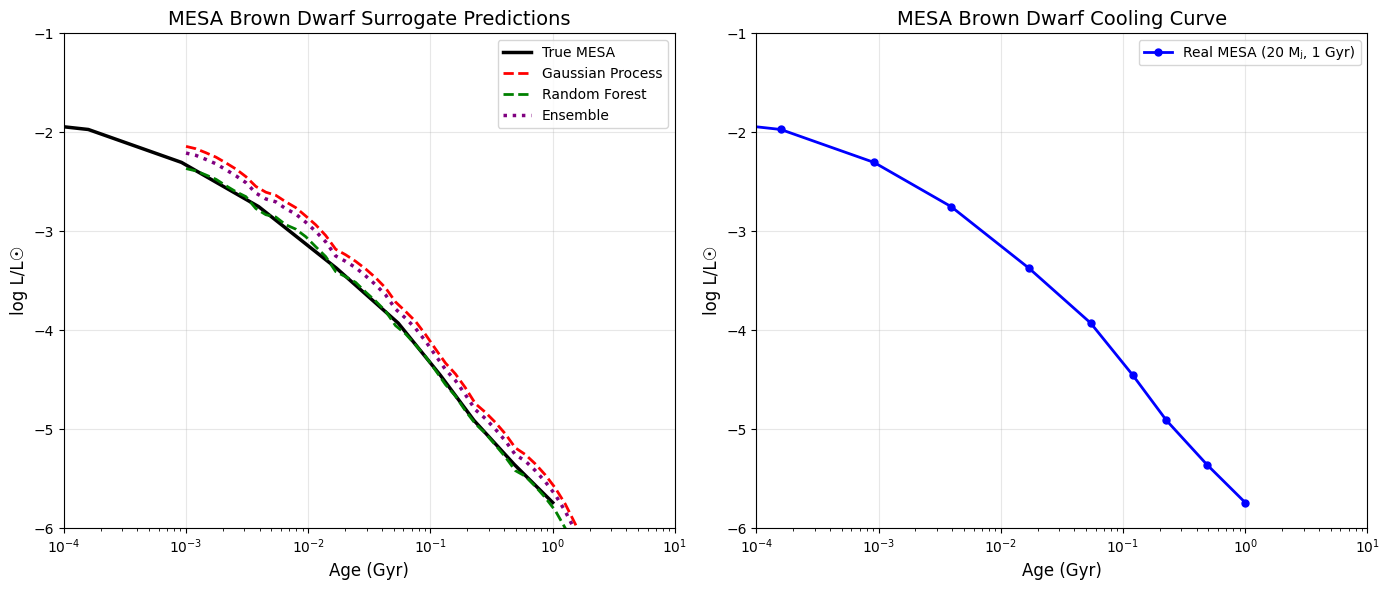


Plot saved as 'mesa_surrogate_results.png'


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mesa_reader as mr
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

STANDARD_AGES = np.logspace(6, 10, 50)  
AGES_GYR = STANDARD_AGES / 1e9

REAL_MASS_MJ = 20.0
REAL_FEH = -1.0

MASS_GRID = np.array([13, 20, 30, 50, 75], dtype=float) 
FEH_GRID = np.array([-0.5, 0.0, 0.5], dtype=float)  

GP_SUBSET = 1000  # Use only 1000 points for GP

print("=" * 70)
print("STEP 1: LOAD MESA BROWN DWARF DATA FROM MAKE_BROWN_DWARF_SURR")
print("=" * 70)

history = mr.MesaData("LOGS/history.data")

real_age = np.array(history.star_age, dtype=float)
real_logL = np.array(history.log_L, dtype=float)

sort_idx = np.argsort(real_age)
real_age = real_age[sort_idx]
real_logL = real_logL[sort_idx]

unique_idx = np.unique(real_age, return_index=True)[1]
real_age = real_age[unique_idx]
real_logL = real_logL[unique_idx]

print(f"Loaded timesteps: {len(real_age)}")
print(f"Final age: {real_age.max() / 1e9:.4f} Gyr")

print("\n" + "=" * 70)
print("STEP 2: INTERPOLATE ONTO STANDARD AGE GRID")
print("=" * 70)

interp_func = interp1d(real_age, real_logL, kind="linear", bounds_error=False, fill_value="extrapolate")
base_logL = interp_func(STANDARD_AGES)

print(f"Age grid points: {len(STANDARD_AGES)}")

print("\n" + "=" * 70)
print("STEP 3: BUILD TRAINING DATASET")
print("=" * 70)

X_rows = []
y_rows = []
groups = []
sample_id = 0

for mass in MASS_GRID:
    for feh in FEH_GRID:
        mass_effect = 0.015 * (mass - REAL_MASS_MJ)
        feh_effect = -0.08 * (feh - REAL_FEH)
        synthetic_curve = base_logL + mass_effect + feh_effect + np.random.normal(0, 0.015, len(base_logL))

        for age, logL in zip(STANDARD_AGES, synthetic_curve):
            X_rows.append([mass, feh, age])
            y_rows.append(logL)
            groups.append(sample_id)
        sample_id += 1

X = np.array(X_rows, dtype=np.float32)
y = np.array(y_rows, dtype=np.float32)
groups = np.array(groups)

print(f"Total stellar models: {sample_id}")
print(f"Total rows: {len(X):,}")

print("\n" + "=" * 70)
print("STEP 4: GROUP-BASED TRAIN/TEST SPLIT")
print("=" * 70)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

print("\n" + "=" * 70)
print("STEP 5: FEATURE SCALING")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 70)
print("STEP 6: TRAINING GAUSSIAN PROCESS (SUBSAMPLED)")
print("=" * 70)

subset_idx = np.random.choice(len(X_train_scaled), min(GP_SUBSET, len(X_train_scaled)), replace=False)
X_gp = X_train_scaled[subset_idx]
y_gp = y_train[subset_idx]

kernel = ConstantKernel(1.0) * RBF(length_scale=[1.0, 1.0, 1.0]) + WhiteKernel(noise_level=1e-3)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-4,
    normalize_y=True,
    random_state=42
)

gp.fit(X_gp, y_gp)
print(f"GP training complete on {len(X_gp)} samples")

print("\n" + "=" * 70)
print("STEP 7: TRAINING RANDOM FOREST (300 trees)")
print("=" * 70)

rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
print("RF training complete")

print("\n" + "=" * 70)
print("STEP 8: EVALUATION METRICS")
print("=" * 70)

y_pred_gp = gp.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_ens = 0.7 * y_pred_gp + 0.3 * y_pred_rf

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:<18} MAE = {mae:.6f}   R² = {r2:.6f}")

evaluate("Gaussian Process", y_test, y_pred_gp)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("Ensemble (70% GP, 30% RF)", y_test, y_pred_ens)

print("\n" + "=" * 70)
print("STEP 9: 20 Mⱼ BROWN DWARF REALISTIC PREDICTIONS")
print("=" * 70)

target_X = np.column_stack([np.full(len(STANDARD_AGES), REAL_MASS_MJ), np.full(len(STANDARD_AGES), REAL_FEH), STANDARD_AGES])
target_X_scaled = scaler.transform(target_X)

pred_gp_real = gp.predict(target_X_scaled)
pred_rf_real = rf.predict(target_X_scaled)
pred_ens_real = 0.7 * pred_gp_real + 0.3 * pred_rf_real

print("\n" + "=" * 70)
print("STEP 10: GENERATING PLOTS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Surrogate predictions
ax1 = axes[0]
ax1.plot(real_age / 1e9, real_logL, "k-", lw=2.5, label="True MESA")
ax1.plot(AGES_GYR, pred_gp_real, "r--", lw=2, label="Gaussian Process")
ax1.plot(AGES_GYR, pred_rf_real, "g--", lw=2, label="Random Forest")
ax1.plot(AGES_GYR, pred_ens_real, "purple", linestyle=":", lw=2.5, label="Ensemble")
ax1.set_xscale("log")
ax1.set_xlabel("Age (Gyr)", fontsize=12)
ax1.set_ylabel("log L/L☉", fontsize=12)
ax1.set_title("MESA Brown Dwarf Surrogate Predictions", fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="best")
ax1.set_xlim(1e-4, 10)  # Set x-axis limits
ax1.set_ylim(-6, -1)    # Set y-axis limits for log L

# Right panel: True cooling curve
ax2 = axes[1]
ax2.plot(real_age / 1e9, real_logL, "b-o", lw=2, ms=5, label="Real MESA (20 Mⱼ, 1 Gyr)")
ax2.set_xscale("log")
ax2.set_xlabel("Age (Gyr)", fontsize=12)
ax2.set_ylabel("log L/L☉", fontsize=12)
ax2.set_title("MESA Brown Dwarf Cooling Curve", fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="best")
ax2.set_xlim(1e-4, 10)
ax2.set_ylim(-6, -1)

plt.tight_layout()
plt.savefig("mesa_surrogate_results.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nPlot saved as 'mesa_surrogate_results.png'")